In [1]:
# HW1a 
# 1. Read dataset and interpolate missing values
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read Excel file
file_path = 'HSI.xlsx'
data = pd.read_excel(file_path, index_col='Date', parse_dates=True)

# Interpolate missing entries using spline method of order 3
interpolated_data = data.interpolate(method='spline', order=3)
interpolated_data

,10 HK,101 HK,1038 HK,11 HK,12 HK,14 HK,142 HK,16 HK,17 HK,179 HK,...,1299 HK,151 HK,322 HK,1928 HK,135 HK,27 HK,2319 HK,823 HK,1 HK,1113 HK
Date,,,,,,,,,,,,,,,,,,,,,
2001-02-01,7.800000,8.950000,12.350000,103.000000,31.330000,13.900000,2.274000,82.250000,9.530000,55.800000,...,NaN,NaN,0.870000,NaN,0.43000,0.520000,NaN,NaN,59.618000,NaN
2001-02-02,7.900000,9.250000,12.400000,102.500000,31.104000,13.900000,2.504000,80.750000,9.569000,53.400000,...,NaN,NaN,0.890000,NaN,0.43500,0.520000,NaN,NaN,58.753000,NaN
2001-02-05,7.850000,8.800000,12.350000,101.000000,30.729000,13.800000,2.572000,79.250000,9.177000,51.000000,...,NaN,NaN,0.880000,NaN,0.42500,0.520000,NaN,NaN,58.753000,NaN
2001-02-06,7.950000,8.900000,12.400000,102.000000,31.180000,13.950000,2.458000,80.000000,9.334000,52.800000,...,NaN,NaN,0.880000,NaN,0.42500,0.520000,NaN,NaN,58.753000,NaN
2001-02-07,8.000000,9.050000,12.800000,103.000000,31.856000,14.150000,2.366000,80.250000,9.412000,52.600000,...,NaN,NaN,0.870000,NaN,0.42000,0.520000,NaN,NaN,59.041000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-03-25,22.326968,14.444603,75.272290,132.578222,47.581482,32.126678,6.346403,93.499131,5.545312,24.468061,...,43.338405,4.592481,7.489581,30.987475,6.35076,28.816242,11.342328,45.814497,100.875712,49.096599
2016-03-28,22.850857,14.560123,74.769781,133.080970,47.745057,32.192848,6.335762,93.303967,5.455252,24.815969,...,44.037841,4.543919,7.392313,31.287327,6.37527,29.162228,11.330682,46.263659,101.112166,49.573566
2016-03-29,21.600000,14.560000,73.850000,134.800000,47.300000,31.900000,5.430000,92.750000,7.220000,23.450000,...,42.450000,5.420000,7.990000,31.200000,6.59000,29.100000,10.880000,45.650000,100.300000,49.250000


In [2]:
# 2. Weekly and Monthly Dataframes
# Weekly dataframe
weekly_data = interpolated_data.resample('W-FRI').mean()

# Monthly dataframe
monthly_data = interpolated_data.resample('ME').mean()

print(weekly_data)
print(monthly_data)

                10 HK     101 HK    1038 HK       11 HK      12 HK      14 HK  \
Date                                                                            
2001-02-02   7.850000   9.100000  12.375000  102.750000  31.217000  13.900000   
2001-02-09   7.910000   8.890000  12.850000  101.800000  31.420200  14.080000   
2001-02-16   8.110000   8.890000  13.650000  101.000000  32.862600  14.050000   
2001-02-23   8.120000   8.880000  13.840000  101.500000  34.094600  13.100000   
2001-03-02   8.360000   9.120000  14.010000   94.900000  35.191800  14.060000   
...               ...        ...        ...         ...        ...        ...   
2016-03-04  21.050000  14.216000  77.830000  134.180000  43.540000  32.090000   
2016-03-11  21.850000  14.628000  75.980000  131.000000  44.710000  33.080000   
2016-03-18  21.690000  14.784000  75.370000  133.720000  46.990000  33.480000   
2016-03-25  21.815394  14.700921  74.824458  133.315644  47.146296  32.215336   
2016-04-01  22.187714  14.66

In [3]:
# 3. Daily, Weekly, and Monthly returns
daily_returns = interpolated_data.pct_change()
weekly_returns = weekly_data.pct_change()
monthly_returns = monthly_data.pct_change()

print(daily_returns)
print(weekly_returns)
print(monthly_returns)

               10 HK    101 HK   1038 HK     11 HK     12 HK     14 HK  \
Date                                                                     
2001-02-01       NaN       NaN       NaN       NaN       NaN       NaN   
2001-02-02  0.012821  0.033520  0.004049 -0.004854 -0.007214  0.000000   
2001-02-05 -0.006329 -0.048649 -0.004032 -0.014634 -0.012056 -0.007194   
2001-02-06  0.012739  0.011364  0.004049  0.009901  0.014677  0.010870   
2001-02-07  0.006289  0.016854  0.032258  0.009804  0.021681  0.014337   
...              ...       ...       ...       ...       ...       ...   
2016-03-25  0.040884 -0.010644  0.011724 -0.001670  0.029902  0.013460   
2016-03-28  0.023464  0.007997 -0.006676  0.003792  0.003438  0.002060   
2016-03-29 -0.054740 -0.000008 -0.012302  0.012917 -0.009322 -0.009097   
2016-03-30  0.020833  0.010989  0.026405  0.008902  0.026427  0.029781   
2016-03-31  0.009070  0.006793  0.000660  0.008088 -0.018538  0.006088   

              142 HK     16 HK     17

In [4]:
# 4. Covariance matrix for weekly data
cov_matrix = weekly_data.cov()
cov_matrix.to_csv('covHSI.csv')

print(cov_matrix)

              10 HK      101 HK     1038 HK       11 HK       12 HK  \
10 HK    230.894445  128.401099  165.957870  190.797976  100.798547   
101 HK   128.401099   77.207198   76.388641  112.467819   59.447266   
1038 HK  165.957870   76.388641  266.425133  230.473554  112.362220   
11 HK    190.797976  112.467819  230.473554  399.772720  162.151515   
12 HK    100.798547   59.447266  112.362220  162.151515   86.874559   
...             ...         ...         ...         ...         ...   
27 HK    143.323262   57.792358  230.301669  184.231097   92.114038   
2319 HK   41.880289   21.475818   51.266721   54.296275   30.320808   
823 HK    35.349688   -0.412130  157.705309   94.865150   51.712102   
1 HK     183.568075   98.916595  266.643315  322.750835  161.015898   
1113 HK   42.618374   24.536085  -30.848626   70.290839   31.201982   

              14 HK     142 HK       16 HK      17 HK      179 HK  ...  \
10 HK    132.043886  38.191815  339.170152  39.156032 -103.499648  ...   

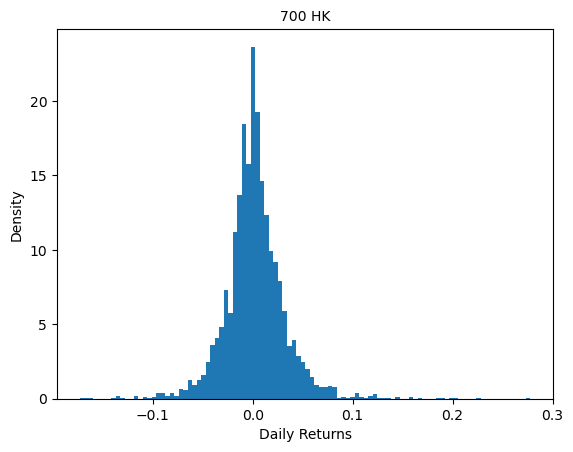

In [5]:
# 5. Histogram for tencent (700 HK)
import matplotlib.pyplot as plt
from docx import Document

# Only use tencent values and drop the NA values
tencent_returns = daily_returns['700 HK'].dropna()

# Plot histogram
plt.hist(tencent_returns, bins=100, density=True)
plt.title('700 HK', fontsize=10)
plt.xlabel('Daily Returns')
plt.ylabel('Density')

# Save histogram as png file
plt.savefig('tencent_histogram.png')

# Create a Word document and insert the histogram
doc = Document()
doc.add_heading('Tencent Daily Returns Histogram', level=1)
doc.add_picture('tencent_histogram.png')
doc.save('Graph.doc')

# Show the plot
plt.show()

In [6]:
# 6. Standard deviation loop
# Empty list to store multiple dataframes
monthly_volatility_list = []

# Loop through each stock and each month
for stock in daily_returns.columns:
    for month in daily_returns.index.month.unique():
        for year in daily_returns.index.year.unique():
            month_data = daily_returns[(daily_returns.index.month == month) & (daily_returns.index.year == year)][stock]
            std_dev = month_data.std()
            # Temp dataframe
            temp_df = pd.DataFrame({
                'Stock': [stock],
                'Year': [year],
                'Month': [month],
                'StdDev': [std_dev]
            })
            # Append datafram to list
            monthly_volatility_list.append(temp_df)

# Concatenate all DataFrames in the list into a single DataFrame
monthly_volatility = pd.concat(monthly_volatility_list)

# Output the result to a CSV file
monthly_volatility.to_csv('HSI_vol.csv')

In [7]:
# 7. Question 6 but using 'resample' function
# Create empty dataframe this time 
monthly_volatility = pd.DataFrame()

for stock in daily_returns.columns:
    # Use resample function 
    monthly_stdev = daily_returns[stock].resample('ME').std()

    #Temp dataframe
    temp_df = monthly_stdev.reset_index()
    temp_df.columns = ['Date', 'StdDev']  
    temp_df['Stock'] = stock  
    temp_df['Year'] = temp_df['Date'].dt.year 
    temp_df['Month'] = temp_df['Date'].dt.month

    monthly_volatility = pd.concat([monthly_volatility, temp_df[['Stock', 'Year', 'Month', 'StdDev']]])

monthly_volatility.to_csv('HSI_vol.csv')

In [8]:
# HW1b
# 1. Construct same monthly return series 
import pandas as pd

# Read the Excel file
df = pd.read_excel('HSI.xlsx', index_col=0)

# Interpolate missing entries
df_interpolated = df.interpolate(method='spline', order=3)

# Create monthly DataFrame and calculate monthly returns
monthly_df = df_interpolated.resample('ME').last()
monthly_returns = monthly_df.pct_change()

monthly_returns

,10 HK,101 HK,1038 HK,11 HK,12 HK,14 HK,142 HK,16 HK,17 HK,179 HK,...,1299 HK,151 HK,322 HK,1928 HK,135 HK,27 HK,2319 HK,823 HK,1 HK,1113 HK
Date,,,,,,,,,,,,,,,,,,,,,
2001-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-03-31,-0.195266,0.000000,-0.095745,-0.024259,-0.167727,-0.171329,-0.178786,-0.143678,-0.239577,-0.049808,...,NaN,NaN,0.238532,NaN,0.018519,-0.090909,NaN,NaN,-0.134918,NaN
2001-04-30,0.085089,-0.034441,0.019478,0.014210,-0.087100,-0.112488,-0.025988,-0.030785,0.018404,0.215794,...,NaN,NaN,-0.340788,NaN,0.291527,0.077359,NaN,NaN,0.086120,NaN
2001-05-31,-0.003877,0.011861,-0.026799,-0.057590,0.004368,-0.020635,-0.116926,0.007526,-0.018071,-0.101211,...,NaN,NaN,0.292228,NaN,0.238844,0.039580,NaN,NaN,-0.042689,NaN
2001-06-30,0.027211,0.052941,0.067194,-0.075145,-0.049473,-0.033981,0.018361,-0.034364,-0.049981,-0.210332,...,NaN,NaN,0.008696,NaN,-0.136364,-0.035714,NaN,NaN,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-11-30,-0.060391,-0.045216,-0.058905,-0.014727,-0.038268,-0.049347,-0.092279,-0.082772,-0.070999,-0.012302,...,0.015351,-0.057276,-0.157658,-0.069272,0.070978,-0.144465,-0.180611,0.015070,-0.045070,-0.072477
2015-12-31,-0.047259,-0.028634,0.057437,0.049822,-0.005236,-0.030534,0.066390,-0.017838,-0.007772,-0.055160,...,0.006479,-0.052545,-0.014260,0.013359,0.016200,0.072368,0.024311,-0.015907,0.028515,-0.002967
2016-01-31,-0.152778,-0.191610,0.013928,-0.128814,-0.115789,-0.055118,0.040856,-0.104701,-0.177546,-0.135593,...,-0.080472,-0.119584,-0.204340,0.009416,-0.160870,-0.014315,-0.150316,-0.044181,-0.078872,-0.173611


In [9]:
# 2. Find A, B, and C from equations in lecture 2 
# Expected returns 
R = monthly_returns.mean()

# Covariance matrix
omega = monthly_returns.cov()

# Inverse of cov matrix
omega_inv = np.linalg.inv(omega)

# Indicator Function
indicator = np.ones(len(R))

# Calculate A, B, C
A = R.transpose() @ omega_inv @ R
B = R.transpose() @ omega_inv @ indicator
C = indicator.transpose() @ omega_inv @ indicator

print(f'A = {A:.5f}')
print(f'B = {B:.5f}')
print(f'C = {C:.5f}')

A = 0.85751
B = 13.24539
C = 1525.43987


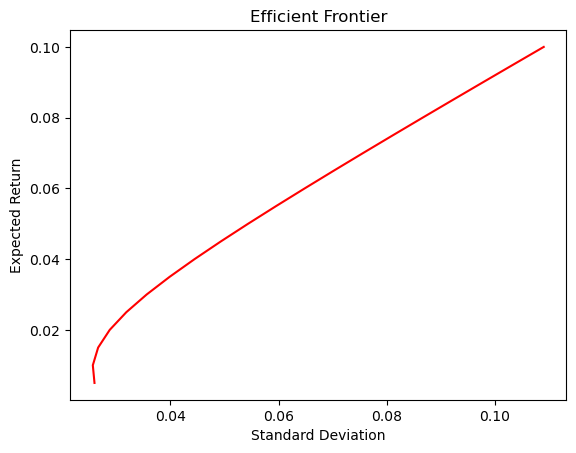

In [10]:
# 3. Efficient frontier without risk-free rate
# Params
mu_p_range = np.arange(0.005, 0.105, 0.005)
weights = []
stdev = []

for mu_p in mu_p_range:
    lambda_val = (mu_p * C - B) * (A * C - B**2)**-1
    gamma_val = (A - B * mu_p) * (A * C - B**2)**-1

    alpha_p = (lambda_val * omega_inv @ R) + (gamma_val * omega_inv @ indicator)

    weights.append(alpha_p)
    stdev_p = np.sqrt(alpha_p.transpose() @ omega @ alpha_p)
    stdev.append(stdev_p)

# Make weights list into dataframe
weights_df = pd.DataFrame(weights, index=[f"{mu_p:.3f}" for mu_p in mu_p_range], columns=monthly_returns.columns)

plt.plot(stdev, mu_p_range, color='red')
plt.title('Efficient Frontier')
plt.xlabel('Standard Deviation')
plt.ylabel('Expected Return')
plt.show()

Sum of tangency portfolio weights: 1.00000
Tangency portfolio expected return: 0.06731
Tangency portfolio standard deviation: 0.07270


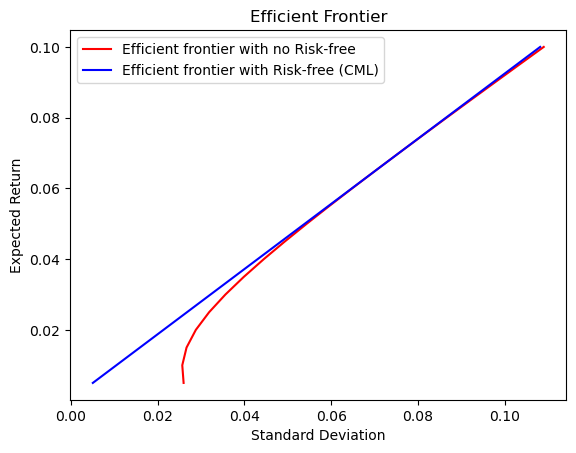

In [11]:
# 4. Efficient frontier with risk-free rate
# Params
rf_annual = 0.02
rf_rate = (1 + rf_annual) ** (1/52) - 1
weights_rf = []

# Portfolio of risky assests = tangency portfolio
excess_returns = R - rf_rate * indicator
numerator = omega_inv @ excess_returns
denominator = indicator.transpose() @ omega_inv @ excess_returns
w_q = numerator / denominator  

# Verify tangency portfolio equates to 1
weight_sum = np.sum(w_q)
print(f'Sum of tangency portfolio weights: {weight_sum:.5f}')

# Expected returns and standard deviation of tangency portfolio
mu_q = w_q.transpose() @ R
stdev_q = np.sqrt(w_q.transpose() @ omega @ w_q)

print(f'Tangency portfolio expected return: {mu_q:.5f}')
print(f'Tangency portfolio standard deviation: {stdev_q:.5f}')

for mu_p in mu_p_range:
    # Tangency portfolio proportion invested
    w_in_q = (mu_p - rf_rate) / (mu_q - rf_rate)

    # Weight in each asset = proportion in tangency portfolio * tangency portfolio weight
    weights_in_assets = w_in_q * w_q
    
    # Calculate weight in risk-free asset (1 - sum of weights in risky assets)
    weight_in_rf = 1 - w_in_q
    
    # Combine all weights (including risk-free asset)
    all_weights = np.append(weights_in_assets, weight_in_rf)
    
    weights_rf.append(all_weights)

# Make weights with risk-free list into dataframe
columns_rf = list(monthly_returns.columns) + ['Risk-Free Asset']
weights_rf_df = pd.DataFrame(
    weights_rf, 
    index=[f"{mu_p:.3f}" for mu_p in mu_p_range], 
    columns=columns_rf
)

# Calculate CML points for plotting
stdev_rf = []
for mu_p in mu_p_range:
    w_in_q = (mu_p - rf_rate) / (mu_q - rf_rate)
    stdev_p = w_in_q * stdev_q
    stdev_rf.append(stdev_p)
    
plt.plot(stdev, mu_p_range, color='red', label='Efficient frontier with no Risk-free')
plt.plot(stdev_rf, mu_p_range, 'blue', label='Efficient frontier with Risk-free (CML)')
plt.title('Efficient Frontier')
plt.xlabel('Standard Deviation')
plt.ylabel('Expected Return')
plt.legend()
plt.show()

In [12]:
# 5. Weights of portfolios in csv
# Without risk-free asset 3.
weights_df.to_csv('weights_withoutRf.csv')

# With risk-free asset 4.
weights_rf_df.to_csv('weights_withRf.csv')